In [1]:
! pip install kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! chmod 600 ~/.kaggle/kaggle.json

In [4]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:02<00:00, 138MB/s]



In [5]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [6]:
! pip install kaggle wandb --quiet

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Data loading

In [8]:
df = pd.read_csv('icml_face_data.csv')
df.columns = df.columns.str.strip()
print(df.shape)
print(df['Usage'].value_counts())
df.head(3)

(35887, 3)
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...


In [9]:
EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
PIXELS_COL  = ' pixels' if ' pixels' in df.columns else 'pixels'
EMOTION_COL = 'emotion'
USAGE_COL   = 'Usage'

class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.labels = df[EMOTION_COL].values
        pixels = np.array(
            [np.fromstring(p, sep=' ', dtype=np.uint8) for p in df[PIXELS_COL]]
        ).reshape(-1, 48, 48)
        self.images = pixels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx][np.newaxis, :, :]
        img = torch.from_numpy(img).float() / 255.0
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [10]:
MEAN, STD   = 0.5071, 0.2555
BATCH_SIZE  = 128

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomResizedCrop(48, scale=(0.85, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.Normalize(mean=[MEAN], std=[STD]),
])
val_transform = T.Compose([
    T.Normalize(mean=[MEAN], std=[STD]),
])

train_df = df[df[USAGE_COL] == 'Training'].reset_index(drop=True)
val_df   = df[df[USAGE_COL] == 'PublicTest'].reset_index(drop=True)

train_ds = FERDataset(train_df, transform=train_transform)
val_ds   = FERDataset(val_df,   transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 28709 | Val: 3589


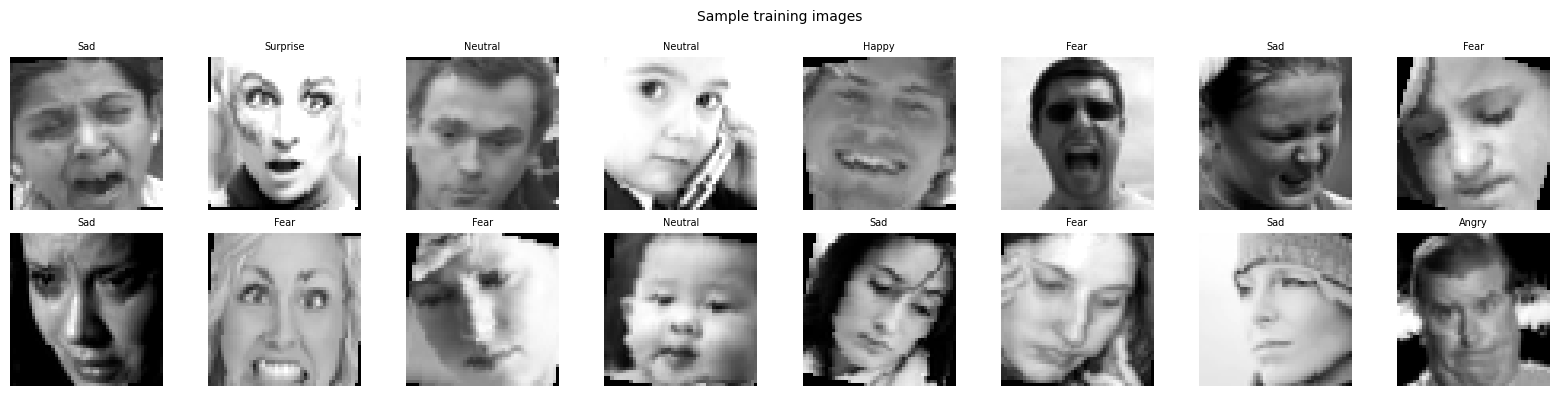

In [11]:
imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, 0].numpy(), cmap='gray')
    ax.set_title(EMOTION_LABELS[lbls[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample training images', fontsize=10)
plt.tight_layout()
plt.show()

## Model

In [12]:
class ChannelAttention(nn.Module):
    """CBAM channel attention: learns WHAT features matter."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x))
        mx  = self.fc(self.max_pool(x))
        scale = self.sigmoid(avg + mx).unsqueeze(-1).unsqueeze(-1)
        return x * scale


class SpatialAttention(nn.Module):
    """CBAM spatial attention: learns WHERE to look in the image."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        scale = self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * scale


class CBAMBlock(nn.Module):
    """Full CBAM: Channel Attention -> Spatial Attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x


class ResBlock(nn.Module):
    """
    Residual block with CBAM attention and Stochastic Depth.
    drop_path_prob: probability of dropping the entire block during training.
    """
    def __init__(self, in_ch, out_ch, stride=1, drop_path_prob=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.cbam = CBAMBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.relu = nn.ReLU(inplace=True)
        self.drop_path_prob = drop_path_prob

    def drop_path(self, x):
        """Stochastic depth: randomly drop block during training."""
        if not self.training or self.drop_path_prob == 0.0:
            return x
        keep = torch.rand(x.shape[0], 1, 1, 1, device=x.device) > self.drop_path_prob
        return x * keep.float() / (1 - self.drop_path_prob)

    def forward(self, x):
        out = self.conv(x)
        out = self.cbam(out)
        out = self.drop_path(out)
        out = out + self.shortcut(x)
        return self.relu(out)


class FinalCNN(nn.Module):
    """
    8-block ResNet with CBAM attention and Stochastic Depth.
    Input: (B, 1, 48, 48)
    """
    def __init__(self, num_classes=7, fc_dropout=0.5, drop_path_prob=0.1):
        super().__init__()

        # Stochastic depth: linearly increase drop prob with depth
        dp = [drop_path_prob * i / 7 for i in range(8)]

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )  # 48x48

        self.layer1 = nn.Sequential(
            ResBlock(32,  64,  stride=2, drop_path_prob=dp[0]),  # 24x24
            ResBlock(64,  64,  stride=1, drop_path_prob=dp[1]),
        )
        self.layer2 = nn.Sequential(
            ResBlock(64,  128, stride=2, drop_path_prob=dp[2]),  # 12x12
            ResBlock(128, 128, stride=1, drop_path_prob=dp[3]),
        )
        self.layer3 = nn.Sequential(
            ResBlock(128, 256, stride=2, drop_path_prob=dp[4]),  # 6x6
            ResBlock(256, 256, stride=1, drop_path_prob=dp[5]),
        )
        self.layer4 = nn.Sequential(
            ResBlock(256, 512, stride=2, drop_path_prob=dp[6]),  # 3x3
            ResBlock(512, 512, stride=1, drop_path_prob=dp[7]),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(fc_dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout * 0.5),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.classifier(x)


model = FinalCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total parameters: {total_params:,}')

FinalCNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (cbam): CBAMBlock(
        (channel): ChannelAttention(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (max_pool): AdaptiveMaxPool2d(output_size=1)
          (fc): Sequential(
            (0): Flatten(start_dim=1, end_dim=-1)
            (1): Linear(in_feature

## Forward & backward pass checks

In [13]:
model.eval()
with torch.no_grad():
    dummy = torch.randn(8, 1, 48, 48).to(DEVICE)
    out   = model(dummy)
print(f'Output shape : {out.shape}')
print(f'Contains NaN : {torch.isnan(out).any().item()}')
print(f'Contains Inf : {torch.isinf(out).any().item()}')
assert out.shape == (8, 7)
print('Forward pass OK')

Output shape : torch.Size([8, 7])
Contains NaN : False
Contains Inf : False
Forward pass OK


In [14]:
model.train()
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
_optimizer = optim.Adam(model.parameters(), lr=1e-3)
single_imgs, single_lbls = next(iter(train_loader))
single_imgs = single_imgs.to(DEVICE)
single_lbls = single_lbls.to(DEVICE)
print('Overfit on 1 batch for 50 steps:')
for step in range(50):
    _optimizer.zero_grad()
    loss = criterion(model(single_imgs), single_lbls)
    loss.backward()
    _optimizer.step()
    if (step + 1) % 10 == 0:
        print(f'  step {step+1:3d}  loss={loss.item():.4f}')
print('Backward pass OK')

Overfit on 1 batch for 50 steps:
  step  10  loss=0.6545
  step  20  loss=0.5999
  step  30  loss=0.5340
  step  40  loss=0.5190
  step  50  loss=0.5001
Backward pass OK


In [15]:
print(f"{'Parameter':<70} {'Shape':<20} {'Grad mean abs':>14}")
print('-' * 107)
dead = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if param.grad is None:
            dead.append(name)
            print(f"{name:<70} {str(tuple(param.shape)):<20} {'NO GRAD':>14}")
        else:
            print(f"{name:<70} {str(tuple(param.shape)):<20} {param.grad.abs().mean().item():>14.6f}")
if dead:
    print(f'Dead params: {dead}')
else:
    print('Gradient flow OK')
model = FinalCNN().to(DEVICE)

Parameter                                                              Shape                 Grad mean abs
-----------------------------------------------------------------------------------------------------------
stem.0.weight                                                          (32, 1, 3, 3)              0.009325
stem.1.weight                                                          (32,)                      0.001836
stem.1.bias                                                            (32,)                      0.001274
layer1.0.conv.0.weight                                                 (64, 32, 3, 3)             0.000211
layer1.0.conv.1.weight                                                 (64,)                      0.000185
layer1.0.conv.1.bias                                                   (64,)                      0.000162
layer1.0.conv.3.weight                                                 (64, 64, 3, 3)             0.000118
layer1.0.conv.4.weight              

## Training

In [16]:
CONFIG = dict(
    experiment      = 'final_cnn_exp1_baseline',
    architecture    = 'FinalCNN_CBAM_StochasticDepth',
    epochs          = 80,
    batch_size      = BATCH_SIZE,
    lr              = 1e-3,
    weight_decay    = 1e-3,
    fc_dropout      = 0.5,
    drop_path_prob  = 0.1,
    label_smoothing = 0.1,
    optimizer       = 'Adam',
    scheduler       = 'OneCycleLR',
    augmentation    = 'flip+rotation15+crop+jitter',
    seed            = SEED,
)

In [17]:
wandb.login()
wandb.init(
    project = 'fer2013-experiments',
    name    = CONFIG['experiment'],
    config  = CONFIG,
    tags    = ['final-cnn', 'cbam', 'stochastic-depth'],
)
wandb.config.update({'total_params': sum(p.numel() for p in model.parameters())})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ntsuk22 (ntsuk22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [18]:
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['epochs'],
    pct_start=0.3,
)


def run_epoch(loader, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == lbls).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)

    history['train_loss'].append(tr_loss)
    history['train_acc' ].append(tr_acc)
    history['val_loss'  ].append(vl_loss)
    history['val_acc'   ].append(vl_acc)

    wandb.log({
        'epoch'              : epoch,
        'train/loss'         : tr_loss,
        'train/acc'          : tr_acc,
        'val/loss'           : vl_loss,
        'val/acc'            : vl_acc,
        'train_val/loss_gap' : abs(tr_loss - vl_loss),
        'train_val/acc_gap'  : abs(tr_acc  - vl_acc),
        'lr'                 : optimizer.param_groups[0]['lr'],
    })

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_final_cnn.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{CONFIG["epochs"]} | train loss {tr_loss:.4f}  acc {tr_acc:.4f} | val loss {vl_loss:.4f}  acc {vl_acc:.4f}')

print(f'Best validation accuracy: {best_val_acc:.4f}')
wandb.run.summary['best_val_acc'] = best_val_acc

Epoch   1/80 | train loss 1.9418  acc 0.2104 | val loss 1.8046  acc 0.2747
Epoch   5/80 | train loss 1.7169  acc 0.3482 | val loss 1.6042  acc 0.4171
Epoch  10/80 | train loss 1.4596  acc 0.4974 | val loss 1.4348  acc 0.5043
Epoch  15/80 | train loss 1.3812  acc 0.5433 | val loss 1.3249  acc 0.5617
Epoch  20/80 | train loss 1.3541  acc 0.5601 | val loss 1.4045  acc 0.5419
Epoch  25/80 | train loss 1.3253  acc 0.5708 | val loss 1.3986  acc 0.5330
Epoch  30/80 | train loss 1.2961  acc 0.5842 | val loss 1.3570  acc 0.5450
Epoch  35/80 | train loss 1.2741  acc 0.5946 | val loss 1.2892  acc 0.5821
Epoch  40/80 | train loss 1.2477  acc 0.6087 | val loss 1.2366  acc 0.6211


KeyboardInterrupt: 

## Analysis

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, CONFIG['epochs'] + 1)
ax1.plot(epochs_range, history['train_loss'], label='train')
ax1.plot(epochs_range, history['val_loss'],   label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss curves'); ax1.legend()
ax2.plot(epochs_range, history['train_acc'], label='train')
ax2.plot(epochs_range, history['val_acc'],   label='val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy curves'); ax2.legend()
plt.suptitle(f"FinalCNN - {CONFIG['experiment']}", fontsize=12)
plt.tight_layout()
wandb.log({'learning_curves': wandb.Image(fig)})
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
model.load_state_dict(torch.load('best_final_cnn.pt', map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs  = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(7)); ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha='right')
ax.set_yticks(range(7)); ax.set_yticklabels(EMOTION_LABELS)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Validation Set')
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
plt.tight_layout()
wandb.log({'confusion_matrix': wandb.Image(fig)})
plt.show()
print('Classification report:')
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS))

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(all_labels, all_preds, target_names=EMOTION_LABELS, output_dict=True)
table_data = [
    [e, round(report[e]['precision'],3), round(report[e]['recall'],3),
     round(report[e]['f1-score'],3), int(report[e]['support'])]
    for e in EMOTION_LABELS
]
wandb.log({'per_class_metrics': wandb.Table(
    columns=['Emotion','Precision','Recall','F1-score','Support'],
    data=table_data,
)})

final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
gap             = final_train_acc - final_val_acc

print('=' * 55)
print(f'  Final train accuracy : {final_train_acc:.4f}')
print(f'  Final val   accuracy : {final_val_acc:.4f}')
print(f'  Train-val gap        : {gap:.4f}')
print('=' * 55)

if final_train_acc < 0.50:
    diagnosis = 'UNDERFITTING - model lacks capacity.'
elif gap > 0.15:
    diagnosis = 'OVERFITTING - large train/val gap. Increase regularization.'
elif gap < 0.05 and final_val_acc < 0.60:
    diagnosis = 'UNDERFITTING with low variance - increase depth or width.'
else:
    diagnosis = 'Reasonable fit - best model achieved.'

print(f'  Diagnosis: {diagnosis}')

wandb.run.summary['final_train_acc'] = final_train_acc
wandb.run.summary['final_val_acc']   = final_val_acc
wandb.run.summary['train_val_gap']   = gap
wandb.run.summary['diagnosis']       = diagnosis
wandb.finish()